# Examen Data Science & AI

| | |
| :--- | :--- |
| **Student Voornaam:** | BRENT |
| **Student Familienaam:** | VERVAET |
| **Studentennummer:** | 187068bv |
| **Datum & uur:** | Donderdag 5 juni 2025, 12:30 |
| **Klasgroep:** | VC |
| **IOEM-student:** | NEE |

Voeg waar nodig codecellen toe voor het uitwerken van de vragen. **LET OP!** De inhoud van de codeblokken wordt niet als antwoord beschouwd! Enkel wat je in de daarvoor voorziene Markdown-cellen noteert telt als antwoord! De inhoud van de codeblokken dient enkel om je antwoord te staven, zodat we kunnen zien hoe je tot je antwoord gekomen bent als het niet zou overeenkomen met de verwachte uitkomst.

**VERGEET DE SCHERMOPNAME NIET!!**

Het examen staat in totaal op 42 punten die worden herleid naar een examencijfer op 20. Veel succes!

------

In [20]:
# Importeren van de nodige packages


# Package imports for data science
import numpy as np
import pandas as pd
import scipy.stats as stats
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

# Package imports for time series analysis
from datetime import datetime
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error,mean_squared_error

## Vraag 1 [2 pt]  
Wat is het meetniveau van elk van deze variabelen:

1. [0.5 pt] het aantal dagen neerslag per maand
1. [0.5 pt] de gemeten luchtdruk
1. [0.5 pt] het grondwaterpeil: zeer laag, laag, normaal, hoog, zeer hoog
1. [0.5 pt] de naam van de wolken: stratus, cumulus, cirrus, altostratus, ...

### Antwoord vraag 1

1. ratio
2. ratio
3. ordinaal
4. nominaal

## Vraag 2 [3 pt]

Naar aanleiding van de droogte, besluit een nieuwszender een enquête te organiseren over de klimaatopwarming. Daarom trekken ze met de volgende vraag op een warme zomerdag naar een overvol strand en ondervragen daar een duizendtal aanwezigen.  
"Gelooft u in de opwarming van de aarde? Helemaal niet akkoord / Niet akkoord / Neutraal / Akkoord / Helemaal akkoord"

1. [1 pt] Is dit een random sample (aselecte steekproef)? Leg uit.
2. [1 pt] Welk type fout(en) wordt hier gemaakt?
3. [1 pt] Is dit een goede sample/steekproef? Leg uit.

### Antwoord vraag 2

1. Dit is geen random sample. Als je mensen op een warme zomerdag dat vraagt is de kans groot dat vele mensen zullen zeggen dat ze wel geloven in opwarming van de aarde.
2. Systematic sampling error (street survey), Accidental non-sampling error(vraag verkeerd begrepen), 
3. Neen: ze ondervragen enkel mensen op het strand, op een warme zomerdag

## Vraag 3 [2 pt]

Combineer elke boxplot met het bijhorende histogram. Verklaar.

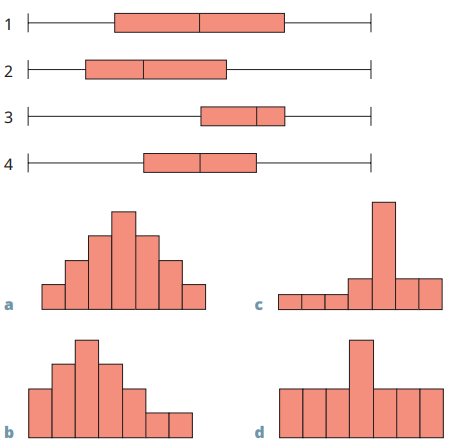

### Antwoord vraag 3

1. -> d: de mean ligt in het mindden en de boxplot is langer omdat het histogram meer verdeeld is
2. -> b: de mean ligt meer aan de linker kant van beide boxplot en histogram
3. -> c: de mean ligt meer aan de rechter kant van beide boxplot en histogram
4. -> a: de mean ligt in het mindden en de boxplot is korter omdat het histogram minder verdeeld is

## Vraag 4 [3 pt]
Een hockeyteam wint met een kans van 0.6 en verliest met een kans van 0.3.
Het team speelt drie wedstrijden in het weekend. Bereken de kans dat het team:

1. [1 pt] alle drie de wedstrijden wint.
2. [1 pt] minstens twee keer wint en niet verliest.
3. [1 pt] één wedstrijd wint, één verliest en één gelijk speelt (in willekeurige volgorde).

$P(W)$ = 0.6

$P(V)$ = 0.3

$P(G)$ = 0.1


### Antwoord vraag 4

1. 0.6 * 0.6 * 0.6 = 21,6 %
2. 0.6 * 0.6 * 0.1 = 3,6 %
3. 0.6 * 0.3 * 0.1 = 1,8 %


## Vraag 5 [3 pt]

Aan een bepaalde instelling voor hoger onderwijs ontvangt iedereen met een eindscore van meer dan 85 in het afstudeerjaar een premie van 1000 EUR en iedereen met een eindscore tussen 80 en 85 ontvangt 500 EUR. Alle anderen krijgen niets. De eindscores zijn normaal verdeeld met een gemiddelde van 63 en een standaardafwijking van 12.

Stel dat er 5000 studenten afstuderen, bereken dan de totale kost voor het verstrekken van de premies voor deze instelling.

Je kan dit berekenen in een drietal stappen. Vermeld duidelijk de gebruikte stappen.

In [21]:
mu = 63
s = 12
n = 5000

p_boven_85 = stats.norm.sf(85, loc=mu, scale=s)
p_tss_80_85 = stats.norm.cdf(85, loc=mu, scale=s) - stats.norm.cdf(80, loc=mu, scale=s)

# aantal_boven_85 = p_boven_85 * n
# aantal_tss_80_85 = p_tss_80_85 * n

aantal_boven_85 = round(p_boven_85 * n)
aantal_tss_80_85 = round(p_tss_80_85 * n)

totale_kost = aantal_boven_85 * 1000 + aantal_tss_80_85 * 500
print(p_boven_85)
print(p_tss_80_85)

print(aantal_boven_85)
print(aantal_tss_80_85)

print(totale_kost)

print('De total kost bedraagt € %.2f'%totale_kost)

0.03337650758481725
0.044913695960000166
167
225
279500
De total kost bedraagt € 279500.00


### Antwoord Vraag 5
De total kost bedraagt € 279500.00


## Vraag 6 [5 pt]

De gemiddelde dagelijkse hoeveelheid schroot van een bepaald fabricageproces is 25.5 kg met een standaardafwijking van 1.6 kg. Er wordt geprobeerd het proces aan te passen in een poging deze hoeveelheid te verminderen.Tijdens een proefperiode werden de onderstaande kilo's schroot geproduceerd. Door de aard van de wijziging werd de dagelijkse variabiliteit van de hoeveelheid schroot niet veranderd. De normale verdeling is van toepassing. Een eerste blik op de cijfers suggereert dat de wijziging effectief is in het verminderen van het schrootniveau. Bevestigt een significantietest dit op 1%-niveau?

1. [1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
2. [1 pt] Formuleer de nulhypothese en de alternatieve hypothese
3. [1 pt] Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde
4. [1 pt] Bereken de p-waarde
5. [1 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.


In [22]:
schroot = [25.70, 24.98, 24.30, 24.43, 23.21, 23.74, 24.03, 26.76, 23.83, 24.02,  25.34, 26.12, 26.46, 23.61, 24.76, 26.92, 25.05, 24.59, 24.47, 25.37, 26.28, 22.50, 24.13, 24.63, 25.08, 24.59, 20.90, 26.70, 23.07, 19.94, 24.30, 22.53, 24.09, 23.63, 23.84]

In [23]:
schroot = pd.Series([25.70, 24.98, 24.30, 24.43, 23.21, 23.74, 24.03, 26.76, 23.83, 24.02,  25.34, 26.12, 26.46, 23.61, 24.76, 26.92, 25.05, 24.59, 24.47, 25.37, 26.28, 22.50, 24.13, 24.63, 25.08, 24.59, 20.90, 26.70, 23.07, 19.94, 24.30, 22.53, 24.09, 23.63, 23.84])

In [24]:
# Properties of the sample:
n = 35              # Sample size
mu = 22.5          # (Hypothetical) population mean
sigma = 1.6         # Population standard deviation (assumed to be known)
m_sample = schroot.mean()    # Sample mean
alpha = 0.01        # Significance level (chosen by the researcher)

In [25]:
p = stats.norm.cdf(m_sample, loc=mu, scale=sigma/np.sqrt(n))

print("p-value: %.5f" % p)
if(p < alpha):
    print("p < a, reject H0")
else:
    print("p > a, do not reject H0")

p-value: 1.00000
p > a, do not reject H0


In [26]:
# Critical value according to the formula in the lecture slides
# g = m0 - stats.norm.isf(a) * s / np.sqrt(n)
# Making use of the loc/scale parameters of isf:

# LEFT TAIL TEST = 1 - alpha

g = stats.norm.isf(1-alpha, loc=mu, scale=(sigma / np.sqrt(n)))
print("Critical value g ≃ %.3f" % g)
if (m_sample > g):
    print("sample mean = %.3f > g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f < g = %.3f: reject H0" % (m_sample, g))

Critical value g ≃ 21.871
sample mean = 24.397 > g = 21.871: do not reject H0


### Antwoord vraag 6

1. Left-tail Z-test
2. 

Step 1. Formulate the hypotheses:

- $H_0: \mu = 22.5$ 
- $H_1: \mu < 22.5$ (na aanpassing zou het schroot moeten minderen)

Step 2. Choose significance level, e.g. $\alpha = 0.01$

Step 3. Calculate the test statistic: $\overline{x} = 24.3971$

Step 4. Determine the $p$-value and reject $H_0$ if $p < \alpha$.

3. $\overline x$ = 24.3971 kg
4. p-value: 1.00000
5. De verandering van het proces heeft niet geholpen voor het verminderen van schroot. We accepteren de null hypothese test. -> nieuwe process heeft meer schroot.

## Vraag 7 [6 pt]

Hieronder staan het aantal Vlaamse zwartbont koeien per jaar. (Bron: StatBel)

1. [1 pt] Maak de onderstaande plot

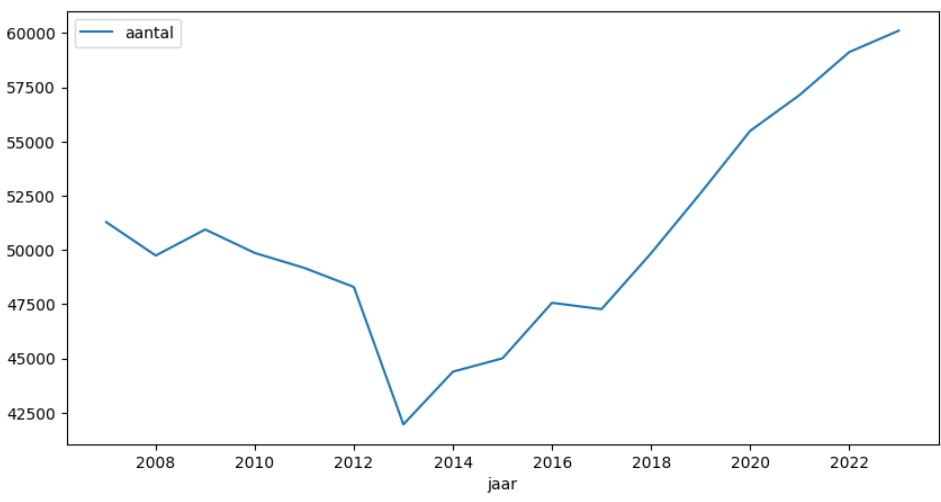

2. [1 pt] Sinds 2013 ontwaren we een stijgende trend. Wat is bij benadering het groeipercentage per jaar sinds 2013?
3. [1 pt] Hoeveel Vlaamse zwartbont koeien zullen er bij benadering zijn in 2027?
4. [1 pt] Met hoeveel eenheden nam het aantal zwartbont koeien af tussen 2007 en 2017?
5. [1 pt] Maak een plot waarop duidelijk te zien is in welk jaar het aantal koeien weer op het niveau van 2007 was.
6. [1 pt] Hoeveel jaren telde men meer dan 55000 zwartbont koeien? (Berekenen, niet gewoon aflezen!)


In [27]:
dfzwartbont = pd.DataFrame(data={
    'jaar': [2007,  2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'aantal': [51289, 49749, 50949, 49867, 49177, 48297, 41966, 44395, 45010, 47568, 47277, 49854, 52627, 55494, 57150, 59125, 60114]
})

<Axes: xlabel='jaar'>

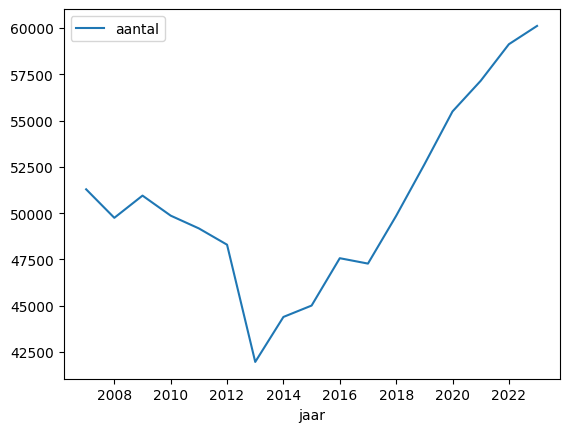

In [28]:
# dfzwartbont.set_index(['jaar'])
dfzwartbont.plot(x='jaar')


### Antwoord vraag 7

1. dfzwartbont.plot(x='jaar')
2. ...
3. ...
4. ...
5. ...
6. ...


## Vraag 8 [9 pt]

In de onderstaande dataframe staat het gemiddelde vetgehalte in melk (in procent) per maand. (Bron: StatBel)

1. [1 pt] Converteer maand naar een datum notatie en stel maand in als index van de dataframe
2. [1 pt] Maak de onderstaande grafiek  

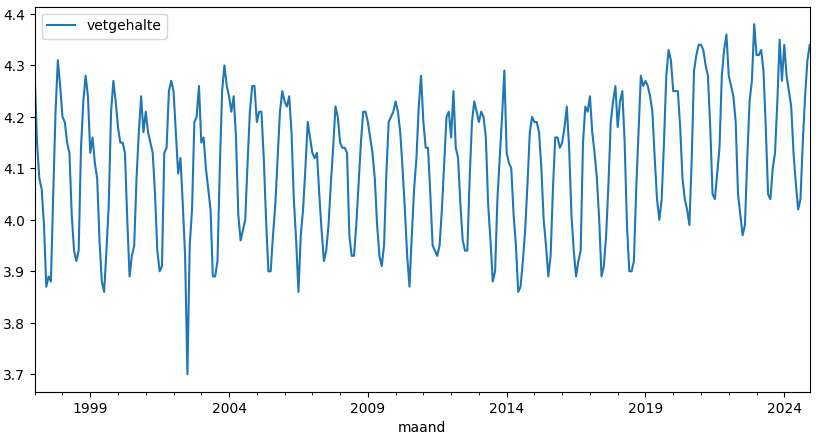

3. [1 pt] Splits de data op in trainingsdata (1997 tot en met 2021) en testdata (2022 tot en met 2024)
4. [1 pt] Train een geschikt model op de trainingsdata.
5. [1 pt] Bepaal hoe goed het model presteert op de testdata.
6. [1 pt] Bereken het gemiddelde te verwachten vetgehalte voor 2025.
7. [1 pt] Op de bovenstaande plot lijkt 1 waarde in het jaar 2002 fout. Bepaal een manier om vlug te weten over welke waarde het gaat.
8. [1 pt] We zouden deze waarde in de dataset willen vervangen door een meer geschikte waarde. Bedenk en geef een snelle manier om een meer accurate waarde te vinden. Wat is een meer geschikte waarde?
9. [1 pt] Het lijkt erop dat de huidige trend heel licht stijgend is. Wordt dit bevestigd door het model? Ja of nee? Leg kort uit.



In [29]:
dfmelk = pd.DataFrame(data={
    'maand': ['1997/01/01', '1997/02/01', '1997/03/01', '1997/04/01', '1997/05/01', '1997/06/01', '1997/07/01', '1997/08/01', '1997/09/01', '1997/10/01', '1997/11/01', '1997/12/01', '1998/01/01', '1998/02/01', '1998/03/01', '1998/04/01', '1998/05/01', '1998/06/01', '1998/07/01', '1998/08/01', '1998/09/01', '1998/10/01', '1998/11/01', '1998/12/01', '1999/01/01', '1999/02/01', '1999/03/01', '1999/04/01', '1999/05/01', '1999/06/01', '1999/07/01', '1999/08/01', '1999/09/01', '1999/10/01', '1999/11/01', '1999/12/01', '2000/01/01', '2000/02/01', '2000/03/01', '2000/04/01', '2000/05/01', '2000/06/01', '2000/07/01', '2000/08/01', '2000/09/01', '2000/10/01', '2000/11/01', '2000/12/01', '2001/01/01', '2001/02/01', '2001/03/01', '2001/04/01', '2001/05/01', '2001/06/01', '2001/07/01', '2001/08/01', '2001/09/01', '2001/10/01', '2001/11/01', '2001/12/01', '2002/01/01', '2002/02/01', '2002/03/01', '2002/04/01', '2002/05/01', '2002/06/01', '2002/07/01', '2002/08/01', '2002/09/01', '2002/10/01', '2002/11/01', '2002/12/01', '2003/01/01', '2003/02/01', '2003/03/01', '2003/04/01', '2003/05/01', '2003/06/01', '2003/07/01', '2003/08/01', '2003/09/01', '2003/10/01', '2003/11/01', '2003/12/01', '2004/01/01', '2004/02/01', '2004/03/01', '2004/04/01', '2004/05/01', '2004/06/01', '2004/07/01', '2004/08/01', '2004/09/01', '2004/10/01', '2004/11/01', '2004/12/01', '2005/01/01', '2005/02/01', '2005/03/01', '2005/04/01', '2005/05/01', '2005/06/01', '2005/07/01', '2005/08/01', '2005/09/01', '2005/10/01', '2005/11/01', '2005/12/01', '2006/01/01', '2006/02/01', '2006/03/01', '2006/04/01', '2006/05/01', '2006/06/01', '2006/07/01', '2006/08/01', '2006/09/01', '2006/10/01', '2006/11/01', '2006/12/01', '2007/01/01', '2007/02/01', '2007/03/01', '2007/04/01', '2007/05/01', '2007/06/01', '2007/07/01', '2007/08/01', '2007/09/01', '2007/10/01', '2007/11/01', '2007/12/01', '2008/01/01', '2008/02/01', '2008/03/01', '2008/04/01', '2008/05/01', '2008/06/01', '2008/07/01', '2008/08/01', '2008/09/01', '2008/10/01', '2008/11/01', '2008/12/01', '2009/01/01', '2009/02/01', '2009/03/01', '2009/04/01', '2009/05/01', '2009/06/01', '2009/07/01', '2009/08/01', '2009/09/01', '2009/10/01', '2009/11/01', '2009/12/01', '2010/01/01', '2010/02/01', '2010/03/01', '2010/04/01', '2010/05/01', '2010/06/01', '2010/07/01', '2010/08/01', '2010/09/01', '2010/10/01', '2010/11/01', '2010/12/01', '2011/01/01', '2011/02/01', '2011/03/01', '2011/04/01', '2011/05/01', '2011/06/01', '2011/07/01', '2011/08/01', '2011/09/01', '2011/10/01', '2011/11/01', '2011/12/01', '2012/01/01', '2012/02/01', '2012/03/01', '2012/04/01', '2012/05/01', '2012/06/01', '2012/07/01', '2012/08/01', '2012/09/01', '2012/10/01', '2012/11/01', '2012/12/01', '2013/01/01', '2013/02/01', '2013/03/01', '2013/04/01', '2013/05/01', '2013/06/01', '2013/07/01', '2013/08/01', '2013/09/01', '2013/10/01', '2013/11/01', '2013/12/01', '2014/01/01', '2014/02/01', '2014/03/01', '2014/04/01', '2014/05/01', '2014/06/01', '2014/07/01', '2014/08/01', '2014/09/01', '2014/10/01', '2014/11/01', '2014/12/01', '2015/01/01', '2015/02/01', '2015/03/01', '2015/04/01', '2015/05/01', '2015/06/01', '2015/07/01', '2015/08/01', '2015/09/01', '2015/10/01', '2015/11/01', '2015/12/01', '2016/01/01', '2016/02/01', '2016/03/01', '2016/04/01', '2016/05/01', '2016/06/01', '2016/07/01', '2016/08/01', '2016/09/01', '2016/10/01', '2016/11/01', '2016/12/01', '2017/01/01', '2017/02/01', '2017/03/01', '2017/04/01', '2017/05/01', '2017/06/01', '2017/07/01', '2017/08/01', '2017/09/01', '2017/10/01', '2017/11/01', '2017/12/01', '2018/01/01', '2018/02/01', '2018/03/01', '2018/04/01', '2018/05/01', '2018/06/01', '2018/07/01', '2018/08/01', '2018/09/01', '2018/10/01', '2018/11/01', '2018/12/01', '2019/01/01', '2019/02/01', '2019/03/01', '2019/04/01', '2019/05/01', '2019/06/01', '2019/07/01', '2019/08/01', '2019/09/01', '2019/10/01', '2019/11/01', '2019/12/01', '2020/01/01', '2020/02/01', '2020/03/01', '2020/04/01', '2020/05/01', '2020/06/01', '2020/07/01', '2020/08/01', '2020/09/01', '2020/10/01', '2020/11/01', '2020/12/01', '2021/01/01', '2021/02/01', '2021/03/01', '2021/04/01', '2021/05/01', '2021/06/01', '2021/07/01', '2021/08/01', '2021/09/01', '2021/10/01', '2021/11/01', '2021/12/01', '2022/01/01', '2022/02/01', '2022/03/01', '2022/04/01', '2022/05/01', '2022/06/01', '2022/07/01', '2022/08/01', '2022/09/01', '2022/10/01', '2022/11/01', '2022/12/01', '2023/01/01', '2023/02/01', '2023/03/01', '2023/04/01', '2023/05/01', '2023/06/01', '2023/07/01', '2023/08/01', '2023/09/01', '2023/10/01', '2023/11/01', '2023/12/01', '2024/01/01', '2024/02/01', '2024/03/01', '2024/04/01', '2024/05/01', '2024/06/01', '2024/07/01', '2024/08/01', '2024/09/01', '2024/10/01', '2024/11/01', '2024/12/01'],
    'vetgehalte': [4.28, 4.15, 4.08, 4.06, 3.99, 3.87, 3.89, 3.88, 4.05, 4.21, 4.31, 4.26, 4.20, 4.19, 4.15, 4.13, 4.01, 3.94, 3.92, 3.94, 4.14, 4.23, 4.28, 4.24, 4.13, 4.16, 4.11, 4.08, 3.96, 3.88, 3.86, 3.94, 4.03, 4.21, 4.27, 4.23, 4.18, 4.15, 4.15, 4.13, 4.00, 3.89, 3.93, 3.95, 4.08, 4.17, 4.24, 4.17, 4.21, 4.17, 4.15, 4.13, 4.05, 3.94, 3.90, 3.91, 4.13, 4.14, 4.25, 4.27, 4.25, 4.17, 4.09, 4.12, 4.03, 3.93, 3.70, 3.95, 4.02, 4.19, 4.20, 4.26, 4.15, 4.16, 4.10, 4.06, 4.02, 3.89, 3.89, 3.92, 4.10, 4.25, 4.30, 4.26, 4.24, 4.21, 4.24, 4.16, 4.01, 3.96, 3.98, 4.00, 4.11, 4.21, 4.26, 4.26, 4.19, 4.21, 4.21, 4.12, 4.00, 3.90, 3.90, 3.97, 4.03, 4.12, 4.21, 4.25, 4.23, 4.22, 4.24, 4.17, 4.04, 3.96, 3.86, 3.97, 4.02, 4.10, 4.19, 4.16, 4.13, 4.12, 4.13, 4.05, 3.98, 3.92, 3.94, 3.99, 4.07, 4.14, 4.22, 4.20, 4.15, 4.14, 4.14, 4.13, 3.97, 3.93, 3.93, 3.99, 4.07, 4.15, 4.21, 4.21, 4.19, 4.16, 4.13, 4.08, 3.99, 3.93, 3.91, 3.95, 4.09, 4.19, 4.20, 4.21, 4.23, 4.21, 4.17, 4.10, 4.02, 3.93, 3.87, 3.97, 4.06, 4.12, 4.22, 4.28, 4.19, 4.14, 4.14, 4.05, 3.95, 3.94, 3.93, 3.95, 4.02, 4.11, 4.20, 4.21, 4.16, 4.25, 4.14, 4.12, 4.03, 3.96, 3.94, 3.94, 4.08, 4.19, 4.23, 4.21, 4.19, 4.21, 4.20, 4.16, 4.03, 3.96, 3.88, 3.90, 4.04, 4.12, 4.20, 4.29, 4.13, 4.11, 4.10, 4.01, 3.95, 3.86, 3.87, 3.92, 3.98, 4.07, 4.17, 4.20, 4.19, 4.19, 4.17, 4.10, 4.00, 3.95, 3.89, 3.93, 4.06, 4.16, 4.16, 4.14, 4.15, 4.18, 4.22, 4.14, 4.01, 3.94, 3.89, 3.92, 3.94, 4.15, 4.22, 4.21, 4.24, 4.17, 4.13, 4.08, 4.00, 3.89, 3.91, 3.97, 4.07, 4.19, 4.23, 4.26, 4.18, 4.23, 4.25, 4.15, 3.99, 3.90, 3.90, 3.92, 4.06, 4.17, 4.28, 4.26, 4.27, 4.26, 4.24, 4.21, 4.12, 4.04, 4.00, 4.04, 4.15, 4.28, 4.33, 4.31, 4.25, 4.25, 4.25, 4.18, 4.08, 4.04, 4.02, 3.99, 4.12, 4.29, 4.32, 4.34, 4.34, 4.33, 4.30, 4.28, 4.18, 4.05, 4.04, 4.09, 4.14, 4.28, 4.33, 4.36, 4.28, 4.26, 4.24, 4.19, 4.05, 4.01, 3.97, 3.99, 4.12, 4.23, 4.27, 4.38, 4.32, 4.32, 4.33, 4.29, 4.18, 4.05, 4.04, 4.10, 4.13, 4.23, 4.35, 4.27, 4.34, 4.28, 4.25, 4.22, 4.13, 4.07, 4.02, 4.04, 4.15, 4.24, 4.31, 4.34]
 })

In [30]:
dfmelk["maand"] = pd.to_datetime(dfmelk["maand"])
dfmelk = dfmelk.set_index("maand")


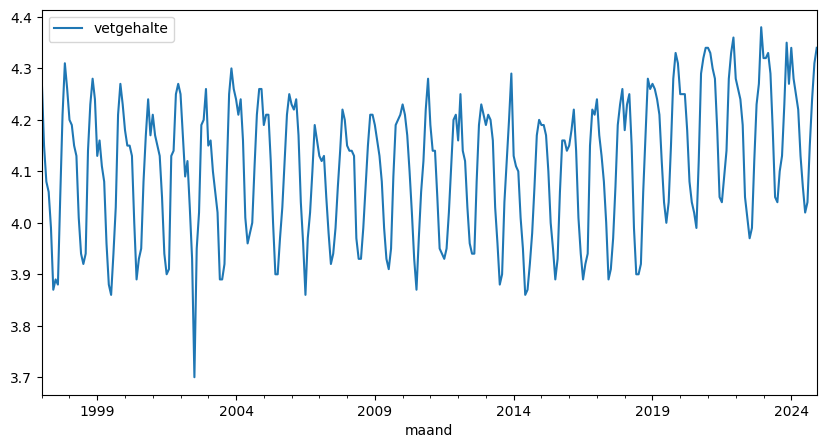

In [31]:
dfmelk.plot( y='vetgehalte', figsize=[10,5]);


In [32]:
train = dfmelk[:-24]
test = dfmelk[-24:]

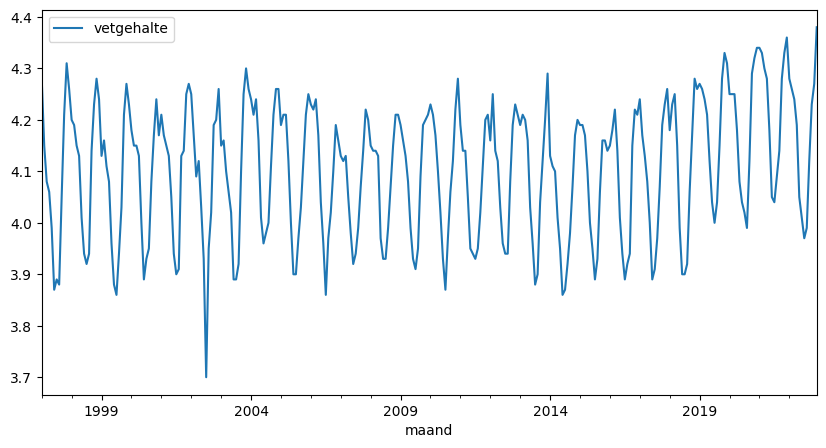

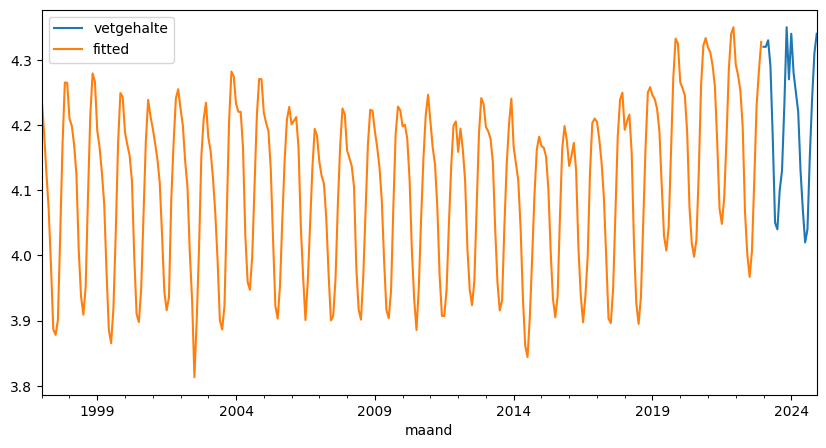

In [33]:
dfmelk_hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24, freq='MS').fit()

train.plot(legend=True, label='train',figsize=[10,5])
test.plot(legend=True, label='test',figsize=[10,5])
(dfmelk_hw.level + dfmelk_hw.season).plot(legend=True, label='fitted');

### Antwoord vraag 8

1. 

dfmelk["maand"] = pd.to_datetime(dfmelk["maand"])

dfmelk = dfmelk.set_index("maand")

2. 

dfmelk.plot( y='vetgehalte', figsize=[10,5]);


3. 

train = dfmelk[:-24]
test = dfmelk[-24:]

4. ...
5. ...
6. ...
7. ...
8. ...
9. ...



## Vraag 9 [5 pt]

In de onderstaande dataframe staat de gemiddelde hoeveelheid melk (in kg) geproduceerd per jaar voor Holstein Zwartbont koeien in Vlaanderen en in Wallonië (Bron: StatBel).
Een eerste blik op de cijfers lijkt te suggereren dat Vlaamse Zwartbont koeien meer melk produceren dan Waalse. Is dit ook zo?

1. [1 pt] Maak een plot
2. [1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
3. [1 pt] Formuleer de nulhypothese en de alternatieve hypothese
4. [1 pt] Bereken de p-waarde
5. [1 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.

In [34]:
melk_zwartbont = pd.DataFrame(data={
    'jaar': [2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'vlaams': [9694,9851,9900,9984,10104,10118,10071,10007,10028,10215,10288,10485,10657,10688,10795,10758,10995],
    'waals': [8628, 8670, 8614, 8853, 9166, 9168, 8775, 8908, 9023, 9098, 8986, 9246, 9391, 9545, 9689, 9517, 9801]
}).set_index('jaar')

<Axes: >

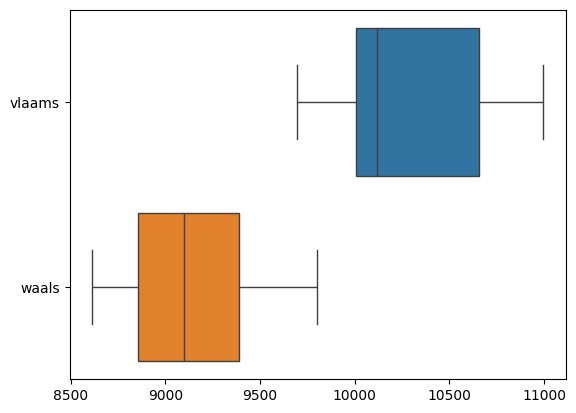

In [35]:
# is het gemiddelde van de ene rij significant verschillend van het gemiddelde van de andere rij?
sns.boxplot(
  data=melk_zwartbont, 
  orient='h'
  )

In [36]:
s, p_value = stats.ttest_rel(melk_zwartbont["waals"],melk_zwartbont["vlaams"], alternative='less') 

print(p_value)

6.229724727264577e-18


### Antwoord vraag 9

1. 

sns.boxplot(
  data=melk_zwartbont, 
  orient='h'
  )

2. independent two sample t-test
3. H0 = geen significant verschile tussen de melk productie in vlaandern of wallonië
   H1 = is melk productie in Vlaanderen significant hoger? (mediaan op plot meer naar rechts!) 
4. 6.229724727264577e-18
5. p_value << 5% => voldoende reden om H0 te verwerpen

 ## Vraag 10 [4 pt]

Een bepaald type kleine landbouwmachines wordt geproduceerd door vier verschillende toeleveringsbedrijven. Het aandeel van de machines die gerepareerd moesten worden in het eerste jaar na verkoop aan de landbouwers is als volgt

| Bedrijf | Totaal aantal machines | Aandeel dat gerepareerd moet worden |
| ------ | ------ | ------ |
| A | 145 | 0.1034 |
| B | 140 | 0.0429 |
| C | 120 | 0.0333 |
| D | 105 | 0.1143 |

Is de verdeling met betrekking tot het vereisen en niet vereisen van reparaties onafhankelijk van het toeleveringsbedrijf? Gebruik het 5% significantieniveau.  

[1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!  
[1 pt] Formuleer de nulhypothese en de alternatieve hypothese  
[1 pt] Bereken de p-waarde  
[1 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.  

In [37]:
dfmachines = pd.DataFrame(data={
    'bedrijf': ['A', 'B', 'C', 'D'],
    'totaal aantal verkochte machines': [145, 140, 120, 105],
    'percentage dat gerepareerd moet worden': [0.10, 0.05, 0.03, 0.12]
}).set_index('bedrijf')

In [38]:
alpha = 0.05               # Significance level
n = sum(dfmachines['totaal aantal verkochte machines'])          # Sample size
k = len(dfmachines['totaal aantal verkochte machines'])          # Number of categories
dof = k - 1                # Degrees of freedom
expected = dfmachines['percentage dat gerepareerd moet worden'] * n  # Expected absolute frequencies in the sample
g = stats.chi2.isf(alpha, df=dof)  # Critical value

# Goodness-of-fit-test in Python:
chi2, p = stats.chisquare(f_obs=dfmachines['totaal aantal verkochte machines'], f_exp=expected)

print("Significance level  ⍺ = %.2f" % alpha)
print("Sample size         n = %d" % n)
print("k = %d; df = %d" % (k, dof))
print("Chi-squared        χ² = %.4f" % chi2)
print("Critical value      g = %.4f" % g)
print("p-value             p = %.4f" % p)

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
2.3333333333333335

### Antwoord vraag 10

1. goodness of fit test
2.  H0: product A, B ,C, D zijn even afhankelijk
    H1: product A, B , C, D zijn onafhankelijk
3. ...
4. ...
